In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

import numpy as np

In [7]:
# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [3]:
from pathlib import Path
import sys
import os
import importlib.util

repo_root = Path('/content/')
path_to_models = os.path.abspath(os.path.join(repo_root, 'src', 'models.py'))

spec = importlib.util.spec_from_file_location("models_direct", path_to_models)
models_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(models_module)

build_model = models_module.build_model
GATv2_Model = models_module.GATv2_Model

print("✅ Success! Models loaded by bypassing src/__init__.py")

✅ Success! Models loaded by bypassing src/__init__.py


In [4]:
# 1. Generate the Dictionary Data (50 nodes, 2D Q/K/V)
def get_data(n=50, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    q, k, v = torch.randn(n, 2), torch.randn(n, 2), torch.randn(n, 2)
    x = torch.cat([q, k, v], dim=1) 
    adj = torch.ones(n, n) # Fully connected
    labels = torch.tensor([torch.argmin(torch.norm(k - q[i], dim=1)) for i in range(n)])
    return x, adj, labels

x, adj, labels = get_data()

In [8]:
# 1. Initialize the standard GAT model
# We use the same hyperparameters (32 hidden, 4 heads) for a fair comparison
model_gat = build_model("gat", nfeat=6, nhid=32, nclass=50, nheads=4, dropout=0.1, alpha=0.2)
optimizer_gat = torch.optim.Adam(model_gat.parameters(), lr=0.01)

print(f"{'Epoch':<8} | {'Loss':<8} | {'Acc':<8} ")
print("-" * 40)

for epoch in range(1001):
    model_gat.train()
    optimizer_gat.zero_grad()
    
    # Forward pass
    out = model_gat(x, adj)
    loss = F.nll_loss(out, labels)
    
    # Backward pass
    loss.backward()
    optimizer_gat.step()
    
    if epoch % 100 == 0:
        model_gat.eval()
        with torch.no_grad():
            pred = model_gat(x, adj)
            acc = (pred.argmax(1) == labels).float().mean().item()
            print(f"{epoch:<8} | {loss.item():<8.4f} | {acc:<8.2%}")

print("-" * 50)
print(f"GAT Final Accuracy: {acc:.2%}")

Epoch    | Loss     | Acc      
----------------------------------------
0        | 4.1231   | 2.00%   
100      | 3.2856   | 10.00%  
200      | 3.2735   | 10.00%  
300      | 3.2811   | 10.00%  
400      | 3.2876   | 10.00%  
500      | 3.2758   | 10.00%  
600      | 3.2826   | 10.00%  
700      | 3.2797   | 10.00%  
800      | 3.2787   | 10.00%  
900      | 3.2791   | 10.00%  
1000     | 3.2759   | 10.00%  
--------------------------------------------------
GAT Final Accuracy: 10.00%


In [5]:
def train_and_eval(model, x_tr, adj_tr, y_tr, x_te, adj_te, y_te,
                   epochs=1000, lr=0.005):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        F.nll_loss(model(x_tr, adj_tr), y_tr).backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        tr_acc = (model(x_tr, adj_tr).argmax(1) == y_tr).float().mean().item()
        te_acc = (model(x_te, adj_te).argmax(1) == y_te).float().mean().item()
    return tr_acc * 100, te_acc * 100

In [12]:
k_values = list(range(4, 21))
res = {'gatv2_te': [], 'gat8h_te': [], 'gat1h_tr': [], 'gat1h_te': []}
 
for k in k_values:
    n = 2 * k
    x_tr, adj_tr, y_tr = get_data(k, seed=42)
    x_te, adj_te, y_te = get_data(k, seed=99)  # different mapping = real test
    print(f"k={k:2d}", end="  ", flush=True)
 
    m = build_model("gat",   nfeat=6, nhid=32, nclass=n, nheads=1, dropout=0.1, alpha=0.2)
    tr, te = train_and_eval(m, x_tr, adj_tr, y_tr, x_te, adj_te, y_te)
    res['gat1h_tr'].append(tr);  res['gat1h_te'].append(te)
    print(f"GAT_1h  train={tr:.0f}% test={te:.0f}%", end="  ", flush=True)
 
    m = build_model("gat",   nfeat=6, nhid=32, nclass=n, nheads=8, dropout=0.1, alpha=0.2)
    _, te = train_and_eval(m, x_tr, adj_tr, y_tr, x_te, adj_te, y_te)
    res['gat8h_te'].append(te)
    print(f"GAT_8h  test={te:.0f}%", end="  ", flush=True)
 
    m = build_model("gatv2", nfeat=6, nhid=32, nclass=n, nheads=1, dropout=0.1, alpha=0.2)
    _, te = train_and_eval(m, x_tr, adj_tr, y_tr, x_te, adj_te, y_te)
    res['gatv2_te'].append(te)
    print(f"GATv2   test={te:.0f}%")

k= 4  GAT_1h  train=50% test=0%  GAT_8h  test=0%  GATv2   test=50%
k= 5  GAT_1h  train=60% test=40%  GAT_8h  test=0%  GATv2   test=0%
k= 6  GAT_1h  train=50% test=33%  GAT_8h  test=0%  GATv2   test=33%
k= 7  GAT_1h  train=43% test=14%  GAT_8h  test=14%  GATv2   test=29%
k= 8  GAT_1h  train=38% test=0%  GAT_8h  test=0%  GATv2   test=25%
k= 9  GAT_1h  train=33% test=33%  GAT_8h  test=0%  GATv2   test=0%
k=10  GAT_1h  train=30% test=30%  GAT_8h  test=30%  GATv2   test=30%
k=11  GAT_1h  train=36% test=9%  GAT_8h  test=0%  GATv2   test=9%
k=12  GAT_1h  train=33% test=8%  GAT_8h  test=8%  GATv2   test=8%
k=13  GAT_1h  train=23% test=0%  GAT_8h  test=15%  GATv2   test=0%
k=14  GAT_1h  train=29% test=0%  GAT_8h  test=0%  GATv2   test=0%
k=15  GAT_1h  train=27% test=0%  GAT_8h  test=0%  GATv2   test=7%
k=16  GAT_1h  train=19% test=12%  GAT_8h  test=6%  GATv2   test=12%
k=17  GAT_1h  train=24% test=6%  GAT_8h  test=6%  GATv2   test=6%
k=18  GAT_1h  train=17% test=6%  GAT_8h  test=6%  GATv2   tes


Saved: dictionary_lookup_chart.png


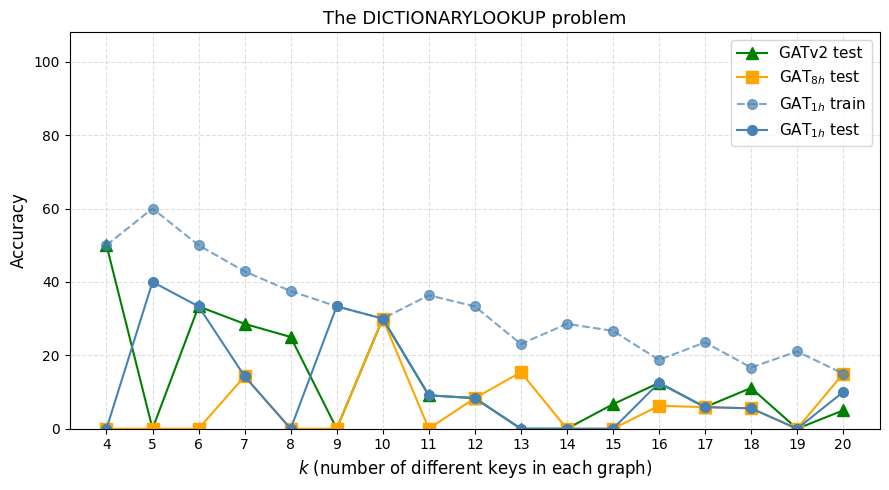

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, res['gatv2_te'],  'g^-',  label='GATv2 test',        markersize=9)
ax.plot(k_values, res['gat8h_te'],  's-',   label='GAT$_{8h}$ test',   markersize=8, color='orange')
ax.plot(k_values, res['gat1h_tr'],  'o--',  label='GAT$_{1h}$ train',  markersize=7, color='steelblue', alpha=0.7)
ax.plot(k_values, res['gat1h_te'],  'o-',   label='GAT$_{1h}$ test',   markersize=7, color='steelblue')
ax.set_xlabel('$k$ (number of different keys in each graph)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('The DICTIONARYLOOKUP problem', fontsize=13)
ax.set_xticks(k_values)
ax.set_ylim(0, 108)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('dictionary_lookup_chart.png', dpi=150)
print("\nSaved: dictionary_lookup_chart.png")

k= 4  GAT_1h  train=50% test=50%  GAT_8h  test=100%  GATv2   test=100%
k= 5  GAT_1h  train=34% test=34%  GAT_8h  test=100%  GATv2   test=100%
k= 6  GAT_1h  train=23% test=20%  GAT_8h  test=100%  GATv2   test=100%
k= 7  GAT_1h  train=14% test=14%  GAT_8h  test=94%  GATv2   test=100%
k= 8  GAT_1h  train=14% test=14%  GAT_8h  test=99%  GATv2   test=100%
k= 9  GAT_1h  train=12% test=12%  GAT_8h  test=92%  GATv2   test=100%
k=10  GAT_1h  train=10% test=10%  GAT_8h  test=80%  GATv2   test=99%
k=11  GAT_1h  train=9% test=9%  GAT_8h  test=91%  GATv2   test=100%
k=12  GAT_1h  train=11% test=10%  GAT_8h  test=90%  GATv2   test=100%
k=13  GAT_1h  train=12% test=11%  GAT_8h  test=70%  GATv2   test=100%
k=14  GAT_1h  train=11% test=9%  GAT_8h  test=74%  GATv2   test=100%
k=15  GAT_1h  train=9% test=7%  GAT_8h  test=60%  GATv2   test=100%
k=16  GAT_1h  train=7% test=7%  GAT_8h  test=63%  GATv2   test=94%
k=17  GAT_1h  train=9% test=8%  GAT_8h  test=65%  GATv2   test=95%
k=18  GAT_1h  train=7% test=7

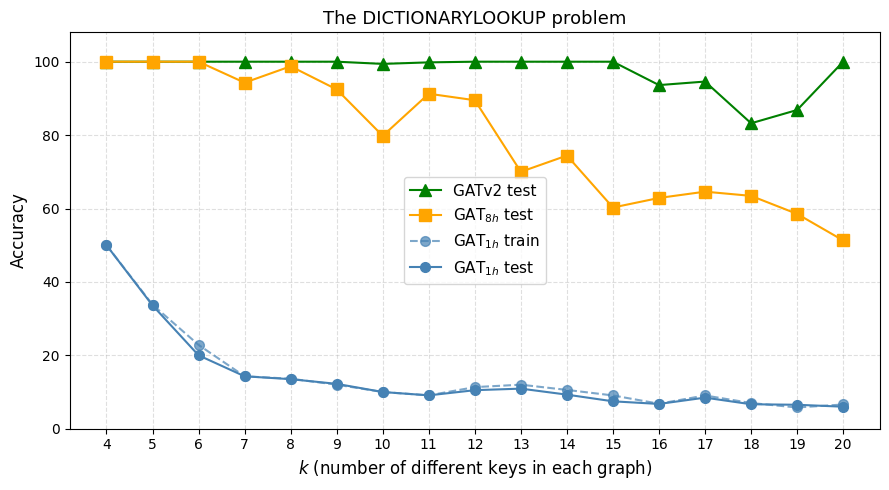

In [9]:
class GATLayer(nn.Module):
    def __init__(self, in_features, out_features, dropout, alpha, concat=True, gain=1.414):
        super(GATLayer, self).__init__()
        self.dropout = dropout
        self.in_features = in_features
        self.out_features = out_features
        self.alpha = alpha
        self.concat = concat

        self.W = nn.Parameter(torch.empty(size=(in_features, out_features)))
        nn.init.xavier_uniform_(self.W.data, gain=gain)

        self.a = nn.Parameter(torch.empty(size=(2 * out_features, 1)))
        nn.init.xavier_uniform_(self.a.data, gain=gain)

        self.leakyrelu = nn.LeakyReLU(self.alpha)

    def forward(self, h, adj, return_attn=False):
        Wh = torch.mm(h, self.W)
        N = Wh.size()[0]

        a_input = torch.cat([Wh.repeat_interleave(N, dim=0), Wh.repeat(N, 1)], dim=1)
        a_input = a_input.view(N, N, 2 * self.out_features)
        e = self.leakyrelu(torch.matmul(a_input, self.a).squeeze(2))

        zero_vec = -1e9 * torch.ones_like(e)
        attention = torch.where(adj > 0, e, zero_vec)
        attention = F.softmax(attention, dim=1)
        attention = F.dropout(attention, self.dropout, training=self.training)
        h_prime = torch.matmul(attention, Wh)

        out = F.elu(h_prime) if self.concat else h_prime
        if return_attn:
            return out, attention
        return out


class GATv2Layer(nn.Module):
    def __init__(self, in_features, out_features, dropout=0.2, alpha=0.2, concat=True):
        super(GATv2Layer, self).__init__()
        self.dropout = dropout
        self.concat = concat

        self.W      = nn.Linear(2 * in_features, out_features, bias=True)
        self.W_prop = nn.Linear(in_features, out_features, bias=False)
        self.a      = nn.Parameter(torch.empty(size=(out_features, 1)))

        nn.init.xavier_uniform_(self.W.weight, gain=1.414)
        nn.init.xavier_uniform_(self.W_prop.weight, gain=1.414)
        nn.init.xavier_uniform_(self.a.data, gain=1.414)
        self.leakyrelu = nn.LeakyReLU(alpha)

    def forward(self, h, adj):
        N = h.size()[0]
        h_i = h.repeat_interleave(N, dim=0)
        h_j = h.repeat(N, 1)

        e = self.leakyrelu(self.W(torch.cat([h_i, h_j], dim=1)))
        e = torch.matmul(e, self.a).squeeze(1).view(N, N)

        zero_vec = -1e9 * torch.ones_like(e)
        attention = torch.where(adj > 0, e, zero_vec)
        attention = F.softmax(attention, dim=1)
        attention = F.dropout(attention, self.dropout, training=self.training)

        Wh = self.W_prop(h)
        h_prime = torch.matmul(attention, Wh)
        return F.elu(h_prime) if self.concat else h_prime

class SingleLayerGAT(nn.Module):
    """One attention layer + linear classifier. Matches the paper's single-layer setup."""
    def __init__(self, nfeat, nhid, nclass, dropout, alpha, nheads):
        super().__init__()
        self.dropout = dropout
        self.heads = nn.ModuleList([
            GATLayer(nfeat, nhid, dropout=dropout, alpha=alpha, concat=True)
            for _ in range(nheads)
        ])
        self.clf = nn.Linear(nhid * nheads, nclass)

    def forward(self, x, adj):
        x = F.dropout(x, self.dropout, training=self.training)
        x = torch.cat([h(x, adj) for h in self.heads], dim=1)
        return F.log_softmax(self.clf(x), dim=1)


class SingleLayerGATv2(nn.Module):
    def __init__(self, nfeat, nhid, nclass, dropout, alpha, nheads):
        super().__init__()
        self.dropout = dropout
        self.heads = nn.ModuleList([
            GATv2Layer(nfeat, nhid, dropout=dropout, alpha=alpha, concat=True)
            for _ in range(nheads)
        ])
        self.clf = nn.Linear(nhid * nheads, nclass)

    def forward(self, x, adj):
        x = F.dropout(x, self.dropout, training=self.training)
        x = torch.cat([h(x, adj) for h in self.heads], dim=1)
        return F.log_softmax(self.clf(x), dim=1)


def get_discrete_data(k, seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    n = 2 * k

    perm = torch.randperm(k)

    q_attr = torch.eye(k)

    k_attr = torch.eye(k)
    k_val  = torch.eye(k)[perm]

    q_feat = torch.cat([q_attr, torch.zeros(k, k)], dim=1)
    k_feat = torch.cat([k_attr, k_val],             dim=1)

    x   = torch.cat([q_feat, k_feat], dim=0)
    adj = torch.ones(n, n)

    labels = torch.cat([
        perm + k,
        torch.arange(k, 2 * k)
    ])
    return x, adj, labels


def get_dataset(k, n_graphs=200, seed_offset=0):
    """Returns a list of (x, adj, labels) with different random mappings."""
    return [get_discrete_data(k, seed=seed_offset + i) for i in range(n_graphs)]


def train_and_eval(model, train_set, test_set, epochs=200, lr=0.005):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    for _ in range(epochs):
        model.train()
        for x, adj, y in train_set:
            x, adj, y = x.to(device), adj.to(device), y.to(device)
            opt.zero_grad()
            k = len(train_set[0][2]) // 2
            out = model(x, adj)
            F.nll_loss(out[:k], y[:k]).backward()
            opt.step()

    def accuracy(dataset):
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, adj, y in dataset:
                x, adj, y = x.to(device), adj.to(device), y.to(device)
                k = len(y) // 2
                pred = model(x, adj).argmax(1)[:k]
                correct += (pred == y[:k]).sum().item()
                total   += k
        return correct / total * 100

    return accuracy(train_set), accuracy(test_set)

k_values = list(range(4, 21))
res = {'gatv2_te': [], 'gat8h_te': [], 'gat1h_tr': [], 'gat1h_te': []}

for k in k_values:
    nfeat = 2 * k
    nclass = 2 * k
    nhid = 64

    train_set = get_dataset(k, n_graphs=100, seed_offset=0)
    test_set = get_dataset(k, n_graphs=50, seed_offset=9999)
    print(f"k={k:2d}", end="  ", flush=True)

    m = SingleLayerGAT(nfeat, nhid, nclass, dropout=0.1, alpha=0.2, nheads=1)
    tr, te = train_and_eval(m, train_set, test_set)
    res['gat1h_tr'].append(tr);  res['gat1h_te'].append(te)
    print(f"GAT_1h  train={tr:.0f}% test={te:.0f}%", end="  ", flush=True)

    m = SingleLayerGAT(nfeat, nhid, nclass, dropout=0.1, alpha=0.2, nheads=8)
    _, te = train_and_eval(m, train_set, test_set)
    res['gat8h_te'].append(te)
    print(f"GAT_8h  test={te:.0f}%", end="  ", flush=True)

    m = SingleLayerGATv2(nfeat, nhid, nclass, dropout=0.1, alpha=0.2, nheads=1)
    _, te = train_and_eval(m, train_set, test_set)
    res['gatv2_te'].append(te)
    print(f"GATv2   test={te:.0f}%")


fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, res['gatv2_te'],  'g^-',  label='GATv2 test',       markersize=9)
ax.plot(k_values, res['gat8h_te'],  's-',   label='GAT$_{8h}$ test',  markersize=8, color='orange')
ax.plot(k_values, res['gat1h_tr'],  'o--',  label='GAT$_{1h}$ train', markersize=7, color='steelblue', alpha=0.7)
ax.plot(k_values, res['gat1h_te'],  'o-',   label='GAT$_{1h}$ test',  markersize=7, color='steelblue')
ax.set_xlabel('$k$ (number of different keys in each graph)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('The DICTIONARYLOOKUP problem', fontsize=13)
ax.set_xticks(k_values)
ax.set_ylim(0, 108)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('dictionary_lookup_chart_v2.png', dpi=150)
print("\nSaved: dictionary_lookup_chart_v2.png")

In [7]:

model_v2 = GATv2_Model(nfeat=6, nhid=32, nclass=50, nheads=4, dropout=0.1, alpha=0.2)
optimizer = torch.optim.Adam(model_v2.parameters(), lr=0.01)

print(f"{'Epoch':<8} | {'Loss':<8} | {'Acc':<8}")
print("-" * 40)

for epoch in range(1501):
    model_v2.train()
    optimizer.zero_grad()
    
    out = model_v2(x, adj)
    loss = F.nll_loss(out, labels)
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0 or epoch == 1500:
        model_v2.eval()
        with torch.no_grad():
            # Get the output and calculate metrics
            current_out = model_v2(x, adj)
            acc = (current_out.argmax(1) == labels).float().mean().item()
            print(f"{epoch:<8} | {loss.item():<8.4f} | {acc:<8.2%} |")

        if acc >= 1.0:
            print("-" * 60)
            print(f"100% Accuracy reached at epoch {epoch}!")
            break

Epoch    | Loss     | Acc     
----------------------------------------
0        | 4.0678   | 8.00%    |
100      | 1.7514   | 66.00%   |
200      | 1.4084   | 78.00%   |
300      | 1.3186   | 82.00%   |
400      | 0.9055   | 92.00%   |
500      | 0.9877   | 94.00%   |
600      | 1.0324   | 96.00%   |
700      | 0.7816   | 96.00%   |
800      | 0.7579   | 96.00%   |
900      | 0.9593   | 92.00%   |
1000     | 0.6813   | 98.00%   |
1100     | 0.9558   | 98.00%   |
1200     | 1.0807   | 92.00%   |
1300     | 0.6386   | 98.00%   |
1400     | 0.7118   | 100.00%  |
------------------------------------------------------------
100% Accuracy reached at epoch 1400!
